# Toronto Raptors Shot Quality Model — A Spatio-Temporal Shot Model

This notebook builds a shot-quality model for Toronto Raptors field-goal attempts
using **spatio-temporal features**: where on the court a shot was taken (space)
combined with when in the game it happened and the score context at that moment (time).

Data comes from ESPN's public NBA API (no key required). Note: NBA's own
stats.nba.com API blocks most cloud/datacenter network ranges, which is why
this project uses ESPN's API instead — the same workaround the open sports-
analytics community commonly uses.

**Pipeline:** fetch play-by-play -> extract Raptors shot attempts -> engineer
spatio-temporal features -> train a gradient-boosted classifier -> evaluate -> visualize.


In [1]:
import sys
sys.path.insert(0, "src")

from fetch_data import fetch_season_shots
from features import build_features
from model import train_and_evaluate
from visualize import plot_shot_map, plot_cumulative_expected_points

import pandas as pd
import matplotlib.pyplot as plt


## 1. Pull Raptors shot data

Start small (a handful of games) to keep this notebook fast to run. Increase
`MAX_GAMES` for a bigger, more robust sample (up to 82 for a full regular season).

In [2]:
SEASON = 2024       # 2024 = the 2023-24 season
MAX_GAMES = 20       # widen this for more data

raw_rows = fetch_season_shots(SEASON, max_games=MAX_GAMES)
print(f"Pulled {len(raw_rows)} Raptors shot attempts across {MAX_GAMES} game(s)")


Pulled 1817 Raptors shot attempts across 20 game(s)


## 2. Engineer spatio-temporal features

- **Spatial:** shot location (x, y) and shot distance in feet (parsed directly
  from ESPN's play-by-play text; near-rim shots like layups/dunks are imputed
  at 2 ft since ESPN doesn't call out a distance for those)
- **Temporal:** elapsed game time in seconds, period, score margin *at the
  moment of the shot*, and a "clutch" flag (4th quarter/OT, under 5 minutes left)


In [3]:
df = build_features(raw_rows)
print(df.shape)
print(f"Make rate: {df['target'].mean():.3%}")
df.head()


(1817, 13)
Make rate: 46.230%


,distance_ft,x,y,game_elapsed_s,period,score_margin,is_clutch,is_three,target,game_id,play_id,text,points_attempted
0,25.0,49,8,20.0,1,0,False,True,0,401584697,4015846977,Scottie Barnes misses 25-foot three point jumper,3
1,24.0,31,24,25.0,1,0,False,True,0,401584697,4015846979,Dennis Schroder misses 24-foot three point jumper,3
2,27.0,13,24,30.0,1,3,False,True,1,401584697,40158469711,Pascal Siakam makes 27-foot three point jumper...,3
3,2.0,28,4,93.0,1,3,False,False,0,401584697,40158469721,Pascal Siakam misses driving layup,2
4,2.0,25,0,95.0,1,5,False,False,1,401584697,40158469723,Jakob Poeltl makes tip shot,2


## 3. Train the shot-quality model

A gradient-boosted classifier (XGBoost) predicting the probability a shot is made.

**A note on accuracy:** unlike the NHL xG model in the companion project, this
model's ROC-AUC will land in the 0.6-0.7 range rather than 0.8+. That's expected,
not a bug — shot location and game time explain only part of whether an NBA shot
goes in. The biggest driver of make probability, defender proximity and contest
level, isn't available from box-score-level play-by-play; it requires actual
player-tracking data (the kind teams collect internally). This model is a
legitimate spatio-temporal baseline, just an honestly limited one given the
public data available.


In [4]:
clf, metrics, (X_test, y_test, proba) = train_and_evaluate(df)
metrics


{'roc_auc': 0.6675473760932944,
 'log_loss': 0.662986398789351,
 'brier_score': 0.2317180633544922,
 'n_test': 364,
 'make_rate_test': np.float64(0.46153846153846156)}

## 4. Visualize: where the good looks are, and how the game unfolds

The shot map shows *where* the Raptors' higher-percentage looks come from.
The expected-vs-actual points chart shows *when* in a game shooting ran hot
or cold relative to expectation — the temporal half of the spatio-temporal story.

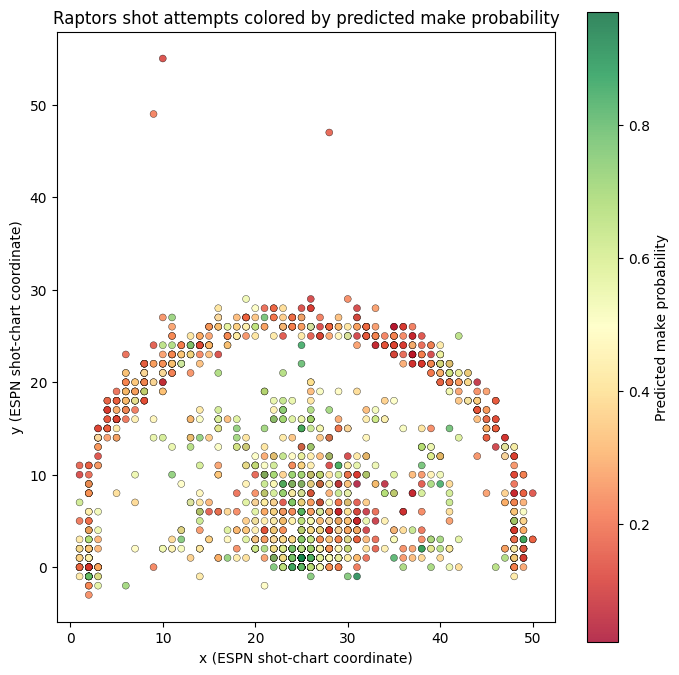

In [5]:
df["make_prob"] = clf.predict_proba(df[X_test.columns])[:, 1]

fig, ax = plt.subplots(figsize=(7, 7))
plot_shot_map(df, ax=ax)
plt.tight_layout()
plt.show()


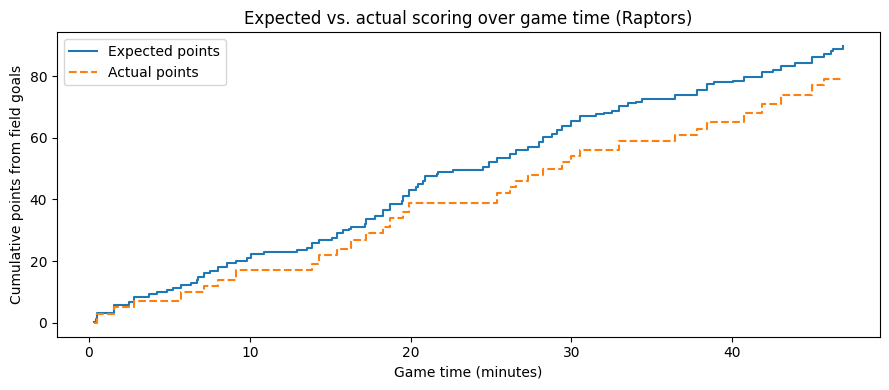

In [6]:
# Pick one game to show expected vs. actual scoring over time
example_game_id = df["game_id"].iloc[0]
game_df = df[df["game_id"] == example_game_id]

fig, ax = plt.subplots(figsize=(9, 4))
plot_cumulative_expected_points(game_df, ax=ax)
plt.tight_layout()
plt.show()


## 5. Next steps to extend this

- Pull a full season (`MAX_GAMES=82`) for a more robust model.
- Add shot-type detail (catch-and-shoot vs. pull-up, transition vs. half-court)
  by parsing more of ESPN's play text.
- Compare against a simple logistic regression baseline (distance + angle only)
  to see how much the temporal/context features actually add.
- Aggregate per-player actual-vs-expected make rate to find over/under-performing
  shooters relative to shot quality (a "shooting skill" analysis).
